In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix
import emcee
import warnings; warnings.simplefilter('ignore')
import time
import corner

In [2]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [3]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

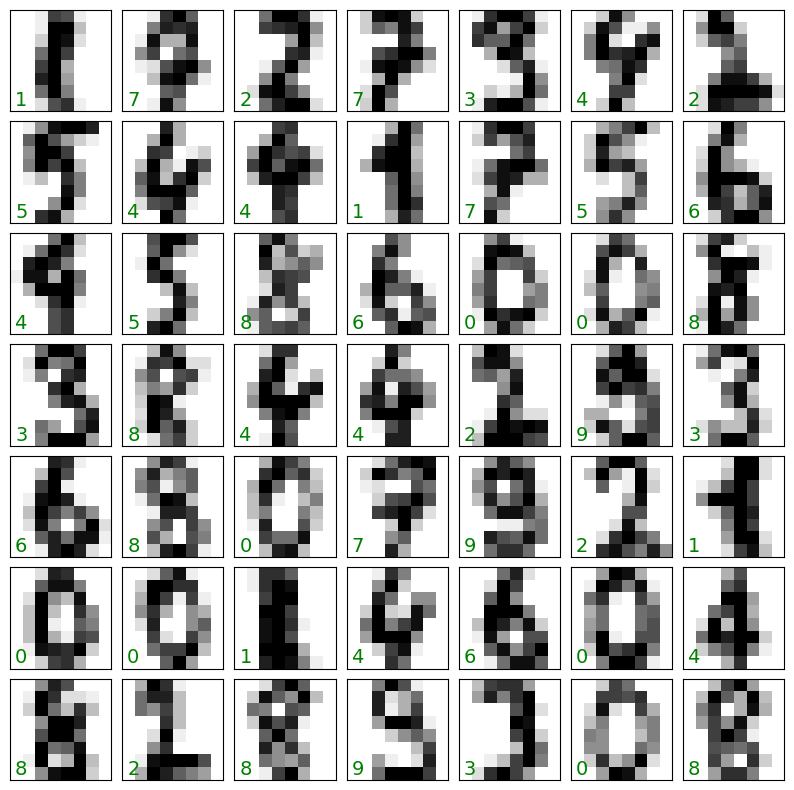

In [4]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [5]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


In [7]:
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
embedding = Isomap(n_components=2) #dimensionality reduction ti dim=2
X_transformed = embedding.fit_transform(digits.data) #transform my previous data in 2 dim
X_transformed

array([[165.5730437 ,  30.04675384],
       [-46.30594879,  48.27623057],
       [-97.10115637,  21.89382574],
       ...,
       [-49.94920887, -24.85038223],
       [ -1.3398207 , -71.51637741],
       [ -9.61500632, -36.82682674]])

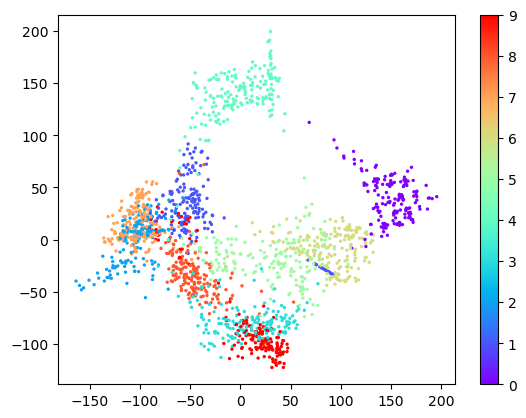

In [19]:
plt.scatter(X_transformed[:,0], X_transformed[:,1], c=digits.target, cmap=plt.colormaps['rainbow'], s=2)
plt.colorbar()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression #classifier
import matplotlib as mpl

#80% of the images as tranining dataset and leaving the other 20% as a validation set
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data,digits.target,random_state=2,train_size=0.8)
clf = LogisticRegression(penalty='l2',max_iter=2000,solver='sag').fit(Xtrain,ytrain)
print(clf, '\n')
clf.fit(Xtrain, ytrain)

ypred_train = clf.predict(Xtrain)
print('Train CM: \n', confusion_matrix(ytrain, ypred_train), '\n')
ypred_test = clf.predict(Xtest)
print('Test CM: \n', confusion_matrix(ytest, ypred_test), '\n')

LogisticRegression(max_iter=2000, solver='sag') 

Train CM: 
 [[146   0   0   0   0   0   0   0   0   0]
 [  0 138   0   0   0   0   0   0   0   0]
 [  0   0 146   0   0   0   0   0   0   0]
 [  0   0   0 147   0   0   0   0   0   0]
 [  0   0   0   0 146   0   0   0   0   0]
 [  0   0   0   0   0 139   0   0   0   0]
 [  0   0   0   0   0   0 146   0   0   0]
 [  0   0   0   0   0   0   0 139   0   0]
 [  0   0   0   0   0   0   0   0 138   0]
 [  0   0   0   0   0   0   0   0   0 152]] 

Test CM: 
 [[31  0  0  0  1  0  0  0  0  0]
 [ 0 41  0  1  0  0  0  0  1  1]
 [ 0  0 31  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  1  1  0]
 [ 0  0  0  0 31  0  0  0  3  1]
 [ 0  1  0  0  1 41  0  0  0  0]
 [ 0  1  0  0  0  0 33  0  1  0]
 [ 0  0  0  0  0  0  0 39  0  1]
 [ 0  0  0  0  0  0  0  0 35  1]
 [ 0  0  0  1  0  1  0  0  1 25]] 



In the test confusion matrix, we can see how 31 zeros have been correctly classified while one has been classified as a 4, and so on for 1, 2, ... 9.

In [11]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(ytrain,ypred_train)
n_acc_train = accuracy_score(ytrain, ypred_train, normalize=False)
print('Train accuracy: ', acc_train, '\n', 
      'Correctly classified train samples: ', n_acc_train, '\n',
      'Total train saples: ', len(ytrain))

acc_test = accuracy_score(ytest,ypred_test)
n_acc_test = accuracy_score(ytest, ypred_test, normalize=False)
print('Test accuracy: ', acc_test, '\n', 
      'Correctly classified trest samples: ', n_acc_test, '\n',
      'Total test saples: ', len(ytest))

Train accuracy:  1.0 
 Correctly classified train samples:  1437.0 
 Total train saples:  1437
Test accuracy:  0.9472222222222222 
 Correctly classified trest samples:  341.0 
 Total test saples:  360
